In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split
from pprint import pprint

In [89]:
df_large = pd.read_csv("rephrased/knowledge_non_knowledge_v3_training_gpt_120b.csv")
df_smaller = pd.read_csv("rephrased/knowledge_non_knowledge_v3_neutral_gpt_120b.csv")
df_out = pd.concat([df_smaller, df_large], ignore_index=False)
print(len(df_out))
df_out.to_csv("datasets/knowledge_non_knowledge_v3_training_unfiltered.csv")

6786


In [3]:
df_ = pd.read_csv("datasets/knowledge_non_knowledge_v3_training_rogue_filtered.csv", sep=",")
df_.head()

,Unnamed: 0,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,ROGUE_precision,...,original_Non_Knowledge_label_FSE_paper_Sol,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments,original_Roberts_label,original_FSE_label,original_binary_NK_label,Label_gpt-120b
0,0,pytorch_pytorch,issue,154997.0,I accidentally discovered that nn.Linear with ...,Observed that nn.Linear with dtype float16 on ...,Neutral,Neutral,long,0.28000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Neutral
1,1,pytorch_pytorch,issue,154997.0,I accidentally discovered that nn.Linear with ...,"When using dtype bfloat16, the same operation ...",Neutral,Neutral,long,0.25000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Neutral
2,2,pytorch_pytorch,issue,154997.0,I accidentally discovered that nn.Linear with ...,"Cloning the sliced tensor (x2 = x1[:, delay:]....",Neutral,Neutral,long,0.25000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Neutral
3,3,pytorch_pytorch,issue,154997.0,I accidentally discovered that nn.Linear with ...,"The test script includes a manual seed, tensor...",Neutral,Neutral,long,0.15625,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Neutral
4,4,pytorch_pytorch,issue,154997.0,I accidentally discovered that nn.Linear with ...,Reference to potential discussion on acceptabl...,Neutral,Neutral,long,0.15000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Neutral


In [121]:
def clean_text(text: str) -> str:
    text = text.replace("\n\n", "")
    return text
df_["Label_Qwen3-4B"] = df_["Label_Qwen3-4B"].apply(clean_text)
df_.head()

,Unnamed: 0,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,ROGUE_precision,...,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments,original_Roberts_label,original_FSE_label,original_binary_NK_label,Label_Qwen3-4B,Label_gpt-120b
0,1894,tensorflow_tensorflow,issue,24828.0,Had same problem with cuda 9.0 and cuDNN 7.0.5...,I ran into the same issue on Ubuntu 16.04 with...,Knowledge,Knowledge,short,0.346154,...,NaN,NaN,NaN,NaN,NaN,0,0,0,Knowledge,Knowledge
1,1139,pytorch_pytorch,issue,155309.0,I think we need a better way to detect aliasin...,I'm not sure we have a solid method to detect ...,Known,Known Unknown,short,0.263158,...,NaN,NaN,NaN,NaN,NaN,2,2,1,Known Unknown,Known unknown
2,1775,tensorflow_tensorflow,issue,24828.0,I tried installting tensorflow 1.12 using both...,Might the pip‑installed TF‑1.12 binary lack th...,Unknown,Known Unknown,long,0.052632,...,Unknown Unknown,The error emerges because the person didn’t kn...,kein Nichtwissen,error?,NaN,2,1,1,Known Unknown,Known Unknown
3,1882,tensorflow_tensorflow,issue,24828.0,Had same problem with cuda 9.0 and cuDNN 7.0.5...,Having the same problem on Ubuntu 16.04 with T...,Knowledge,Knowledge,short,0.360000,...,NaN,NaN,NaN,NaN,NaN,0,0,0,Knowledge,Knowledge
4,2946,numpy_numpy,issue,18004.0,The error is referring to the fact that float(...,Turns out `float(1).exp()` blows up – NumPy do...,Knowledge,Knowledge,short,0.333333,...,NaN,NaN,NaN,NaN,NaN,0,0,0,Knowledge,Knowledge


In [4]:
df_.describe()

,Unnamed: 0,Nr,ROGUE_precision,ROGUE_recall,ROGUE_f1,original_Unnamed: 0.4,original_Unnamed: 0.3,original_Unnamed: 0.2,original_Unnamed: 0.1,original_Unnamed: 0,original_Nr,original_Roberts_label,original_FSE_label,original_binary_NK_label
count,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,1949.943124,93431.363170,0.248588,0.171969,0.182098,49.773116,49.773116,49.773116,49.773116,49.773116,93431.363170,1.099611,1.056566,0.617405
std,1315.097040,75929.669981,0.106688,0.114640,0.098631,29.053462,29.053462,29.053462,29.053462,29.053462,75929.669981,0.953956,0.969171,0.486058
min,0.000000,17501.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17501.000000,-1.000000,-1.000000,0.000000
25%,853.500000,28024.000000,0.173913,0.078125,0.105263,24.000000,24.000000,24.000000,24.000000,24.000000,28024.000000,0.000000,0.000000,0.000000
50%,1706.000000,62075.000000,0.250000,0.156250,0.171429,50.000000,50.000000,50.000000,50.000000,50.000000,62075.000000,2.000000,1.000000,1.000000
75%,2986.500000,154721.000000,0.329583,0.250000,0.250000,75.000000,75.000000,75.000000,75.000000,75.000000,154721.000000,2.000000,2.000000,1.000000
max,4680.000000,252223.000000,0.494505,0.750000,0.516129,100.000000,100.000000,100.000000,100.000000,100.000000,252223.000000,2.000000,3.000000,1.000000


In [22]:
df_changed = df_[df_["Non_knowledge_label_Roberts_Giuliano"] != df_["Label_gpt-120b"]].copy() #.loc[70:100]

In [42]:
df_changed[(df_changed["Non_knowledge_label_Roberts_Giuliano"] == "Known Unknown") & (df_changed["Label_gpt-120b"] == "Knowledge")].loc[2800:3000]

,Unnamed: 0,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,ROGUE_precision,...,original_Non_Knowledge_label_FSE_paper_Sol,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments,original_Roberts_label,original_FSE_label,original_binary_NK_label,Label_gpt-120b
2816,921,pytorch_pytorch,issue,17501.0,"After testing on GPU, if I set the batch size ...","When I run the model on an 8 GB GPU, setting t...",Known,Known Unknown,short,0.113924,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2817,922,pytorch_pytorch,issue,17501.0,"After testing on GPU, if I set the batch size ...",I have observed that the workload finishes qui...,Known,Known Unknown,short,0.075000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2818,923,pytorch_pytorch,issue,17501.0,"After testing on GPU, if I set the batch size ...",Running the training loop on an 8 GB GPU shows...,Known,Known Unknown,short,0.074074,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2819,924,pytorch_pytorch,issue,17501.0,"After testing on GPU, if I set the batch size ...","On an 8 GB graphics card, the program executes...",Known,Known Unknown,short,0.083333,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2820,925,pytorch_pytorch,issue,17501.0,"After testing on GPU, if I set the batch size ...",Testing on an 8 GB GPU reveals that a batch si...,Known,Known Unknown,short,0.102564,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2872,982,pytorch_pytorch,issue,155309.0,The error is likely caused by how torch.export...,The observed failure most probably originates ...,Known,Known Unknown,short,0.371429,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2873,984,pytorch_pytorch,issue,155309.0,The error is likely caused by how torch.export...,The bug likely stems from torch.export mishand...,Known,Known Unknown,short,0.480000,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2874,985,pytorch_pytorch,issue,155309.0,The error is likely caused by how torch.export...,It appears that torch.export does not fully su...,Known,Known Unknown,short,0.347826,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2875,986,pytorch_pytorch,issue,155309.0,The error is likely caused by how torch.export...,"Given the current evidence, the problem seems ...",Known,Known Unknown,short,0.185185,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge
2877,988,pytorch_pytorch,issue,155309.0,The error is likely caused by how torch.export...,It appears that torch.export might be mishandl...,Known,Known Unknown,short,0.194444,...,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,Knowledge


In [43]:
row = 2951

print(df_changed.loc[row, "styles"])
print(df_changed.loc[row, "ROGUE_f1"])
print(df_changed.loc[row, "ROGUE_precision"])
print(df_changed.loc[row, "Non_knowledge_label_Roberts_Giuliano"])
print()
print(df_changed.loc[row, "original_statement"])
print("##############")
print(df_changed.loc[row, "rephrased_statement"])
#print(df_.loc[row, "Label_Qwen3-4B"])
print(df_changed.loc[row, "Label_gpt-120b"])

('Casual/Conversational', 'Exploratory', 'Expand')
0.2222222222222222
0.2692307692307692
Known Unknown

Thank you so much for the detailed and insightful analysis.

I followed your suggestion and tested with:

torch.backends.cudnn.enabled = False

As you anticipated, export on GPU succeeded when disabling cuDNN. This strongly indicates that the issue is indeed related to certain cuDNN-optimized fused kernels, likely being incorrectly traced during export when fake tensors are used.

For completeness, my environment reports the following cuDNN version:

torch.backends.cudnn.version() == 90100

This further supports the hypothesis that some low-level dispatch or fusion within cuDNN is not being properly marked as opaque or guarded during export tracing?

Additionally, I’d like to report that the same issue also occurs when using nn.RNN instead of nn.LSTM. Specifically, like:

self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

This confirms that the problem is not l

In [24]:
fd_changed_groups = df_changed.groupby("Non_knowledge_label_Roberts_Giuliano")["Label_gpt-120b"].value_counts()

In [25]:
fd_changed_groups

Non_knowledge_label_Roberts_Giuliano  Label_gpt-120b 
Knowledge                             Neutral             33
                                      Known Unknown       18
Known Unknown                         Knowledge          464
                                      Neutral            136
                                      Unknown Known        7
                                      Unknown Unknown      3
Neutral                               Knowledge          489
                                      Known Unknown      126
Unknown Knowns                        Known Unknown       23
                                      Knowledge           10
                                      Neutral              6
Unknown Unknown                       Known Unknown      347
                                      Neutral             75
                                      Knowledge           53
Name: count, dtype: int64

In [9]:
df_[df_["ROGUE_precision"] < 0.5]["Repo"].value_counts()

Repo
pytorch_pytorch          2100
numpy_numpy              1712
tensorflow_tensorflow    1498
microsoft_vscode         1125
Name: count, dtype: int64

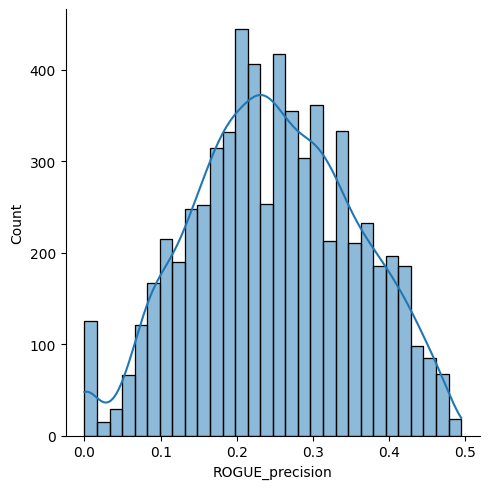

In [10]:
sns.displot(df_, x="ROGUE_precision", kde=True)

In [30]:
def create_Roberts_label_detailed(non_knowledge_type: str) -> int:
    if non_knowledge_type.lower() == "knowledge":
        return 0
    elif non_knowledge_type.lower() == "unknown unknown":
        return 1
    elif non_knowledge_type.lower() == "known unknown":
        return 2
    elif non_knowledge_type.lower() == "error":
        return 3
    else:
        return -1

label_mapping = {"knowledge": 0, "neutral": 1, "non-knowledge": 2}
def create_binary_non_knowledge_label(non_knowledge_type: str) -> int:
    if non_knowledge_type == "Knowledge":
        return 0
    elif non_knowledge_type == "Neutral":
        return 1
    elif non_knowledge_type.lower() in ["known", "irrelevant", "unknown"] or ["unknown unknown", "known unknown", "error", "unknown known"]:
        return 2
    else: # Make Neutral
        return 1

def create_FSE_non_knowledge_label(non_knowledge_type: str) -> int:
    if non_knowledge_type.lower() == "knowledge":
        return 0
    elif non_knowledge_type.lower() == "unknown":
        return 1
    elif non_knowledge_type.lower() == "known":
        return 2
    elif non_knowledge_type.lower() == "irrelevant":
        return 3
    else:
        return -1
    
def create_binary_toxic_label(toxicity_label: str) -> int:
    if toxicity_label == "hateful":
    #     return "negated - toxic"
    # else:
    #     return "negated - healthy"
    # if toxicity_label == "y":
        return 1
    else:
        return 0
    #     return 1
    # else:
    #     return 0

def create_written_toxic_label(toxicity_label: str) -> str:
    if toxicity_label == "hateful":
    #      return "negated - toxic"
    # else:
    #      return "negated - healthy"
    # if toxicity_label == "y":
        return "toxic"
    else:
        return "healthy"
    #     return 1
    # else:
    #     return 0
    
dataset = pd.read_csv("datasets/knowledge_non_knowledge_v3_categorized.csv", sep=",")
#dataset = dataset[dataset["Non_knowledge_label_Roberts_Giuliano"] == dataset["Label_gpt-120b"]].copy()
#dataset = dataset.drop([265, 92])
#dataset["Roberts_label"] = dataset["Non_knowledge_label_Roberts_Giuliano"].apply(create_Roberts_label_detailed)
#dataset["FSE_label"] = dataset["Non_Knowledge_label_FSE_paper_Giuliano"].apply(create_FSE_non_knowledge_label)
dataset["final_label"] = dataset["Non_knowledge_label_Roberts_Giuliano"].apply(create_binary_non_knowledge_label)
#dataset["is_toxic"] = dataset["is_toxic"].apply(create_binary_toxic_label)
#dataset["label_2"] = dataset["is_toxic"].copy()
#dataset["is_toxic"] = dataset["label"].copy()
#dataset["label"] = dataset["label_2"].copy()
#dataset["is_toxic"] = dataset["label_gold"].apply(create_binary_toxic_label)
#dataset["label"] = dataset["label_gold"].apply(create_written_toxic_label)
#dataset["statement"] = dataset["statement"].copy()
dataset["rephrased_statement"] = dataset["statement"]
dataset.to_csv("datasets/knowledge_non_knowledge_v3_categorized.csv", sep=",")
len(dataset)

101

In [46]:
print(pd.crosstab(dataset['Repo'], dataset['final_label']))

final_label              0    1    2
Repo                                
microsoft_vscode       211  230  372
numpy_numpy            309  334  448
pytorch_pytorch        613  427  518
tensorflow_tensorflow  559  311  313


In [26]:
df_in = pd.read_csv("datasets/knowledge_non_knowledge_v3_training_filtered_unbalanced.csv", sep=",")
df_in['stratify_key'] = df_in['Repo'].astype(str) + "_" + df_in['final_label'].astype(str)
df_in['Group_ID'] = df_in['Repo'].astype(str) + "_" + df_in['Nr'].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=1337)

for train_index, test_index in gss.split(df_in, y=df_in['final_label'], groups=df_in['Group_ID']):
    X_train = df_in.iloc[train_index].copy()
    X_test = df_in.iloc[test_index].copy()

X_train = X_train.drop(["Group_ID", "stratify_key"], axis=1)
X_test = X_test.drop(["Group_ID", "stratify_key"], axis=1)

# Placeholder for the final, balanced training data
balanced_train_list = []
min_count = X_train['final_label'].value_counts().min()
# Group by the 'label' column
grouped = X_train.groupby('final_label')

for name, group in grouped:
    # Randomly sample 'min_count' examples from each class group
    # .sample(n=min_count) performs the undersampling
    sampled_group = group.sample(n=min_count, random_state=42) 
    balanced_train_list.append(sampled_group)

# Concatenate the sampled groups back into the final, balanced training DataFrame
X_train_balanced = pd.concat(balanced_train_list)

In [27]:
# Calculate percentages for the Train set
train_dist = X_train.groupby('Repo')['final_label'].value_counts(normalize=True).unstack()
train_dist_balanced = X_train_balanced.groupby('Repo')['final_label'].value_counts(normalize=True).unstack()

# Calculate percentages for the Test set
test_dist = X_test.groupby('Repo')['final_label'].value_counts(normalize=True).unstack()

print("--- Training Set Distribution ---")
print("length:", len(X_train))
print(train_dist.round(3))
print("\n--- Balanced Training Set Distribution ---")
print("length:", len(X_train_balanced))
print(train_dist_balanced.round(3))
print("\n--- Test Set Distribution ---")
print("length:", len(X_test))
print(test_dist.round(3))

--- Training Set Distribution ---
length: 3737
final_label                0      1      2
Repo                                      
microsoft_vscode       0.255  0.283  0.462
numpy_numpy            0.294  0.325  0.381
pytorch_pytorch        0.396  0.276  0.328
tensorflow_tensorflow  0.464  0.261  0.275

--- Balanced Training Set Distribution ---
length: 3150
final_label                0      1      2
Repo                                      
microsoft_vscode       0.229  0.339  0.432
numpy_numpy            0.249  0.384  0.368
pytorch_pytorch        0.356  0.324  0.319
tensorflow_tensorflow  0.417  0.313  0.270

--- Test Set Distribution ---
length: 908
final_label                0      1      2
Repo                                      
microsoft_vscode       0.277  0.283  0.440
numpy_numpy            0.270  0.283  0.447
pytorch_pytorch        0.356  0.248  0.396
tensorflow_tensorflow  0.525  0.275  0.200


In [28]:
X_train_balanced.to_csv("datasets/knowledge_non_knowledge_v3_training_final_group_balanced.csv")
X_test.to_csv("datasets/knowledge_non_knowledge_v3_evaluation_final_group_balanced.csv")

In [ ]:
def get_len(text: str) -> int:
    return len(str(text).strip())
#file_path = f"datasets/cumstrudel_train_issues"
#df_large = pd.read_csv("datasets/code-review-dataset.csv")
#df_smaller = pd.read_csv("datasets/code-review-dataset-smaller.csv")
df_in = pd.read_csv("datasets/hatecheck.csv")
#dataset = df_large.drop(df_smaller.index).copy()
dataset = df_in[~df_in["functionality"].isin(["slur_reclaimed_nh", "target_obj_nh", "target_indiv_nh", "target_group_nh"])]
#dataset["len_text"] = dataset["statement"].apply(get_len)
#q_low = np.quantile(list(dataset["len_text"]), 0.1)
#q_high = np.quantile(list(dataset["len_text"]), 0.9)
df_toxic = dataset[(dataset["is_toxic"] == 1) & (dataset["len_text"] <= q_high) & (dataset["len_text"] >= q_low)].copy()
df_healthy = dataset[(dataset["is_toxic"] == 0) & (dataset["len_text"] <= q_high) & (dataset["len_text"] >= q_low)].copy()
sample_length = len(df_toxic)
print(sample_length)
df_toxic_smaller = df_toxic.sample(300, random_state=42).copy()
df_healthy_smaller = df_healthy.sample(300, random_state=42).copy()
df_out = pd.concat([df_healthy_smaller, df_toxic_smaller], ignore_index=True)
df_out = df_out.sample(frac=1).copy()
df_out.to_csv("datasets/code-review-dataset" + "-mid.csv")

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
df_in = pd.read_csv("datasets/knowledge_non_knowledge_v3_training_filtered_unbalanced.csv", sep=",")
dataset = df_in.copy()#[df_in["functionality"].isin(["slur_reclaimed_nh", "target_obj_nh", "target_indiv_nh", "target_group_nh", "counter_quote_nh", "counter_ref_nh", "ident_neutral_nh", "phrase_question_h", "spell_char_swap_h", "profanity_nh"])]
#groups = dataset["Repo"].unique()
train_idx, test_idx = next(gss.split(dataset, groups=dataset["Repo"]))
train_df = dataset.iloc[train_idx].copy()
test_df = dataset.iloc[test_idx].copy()
df_train_toxic = train_df[(train_df["final_label"] == 1)].copy()
df_train_healthy = train_df[(train_df["final_label"] == 0)].copy()
sample_length_train_toxic = len(df_train_toxic)
sample_length_train_healthy = len(df_train_healthy)
sample_length_train = min(sample_length_train_toxic, sample_length_train_healthy)
df_toxic_smaller = df_train_toxic.sample(sample_length_train, random_state=42).copy()
df_healthy_smaller = df_train_healthy.sample(sample_length_train, random_state=42).copy()
df_train_out = pd.concat([df_healthy_smaller, df_toxic_smaller], ignore_index=True)
df_train_out = df_train_out.sample(frac=1).copy()
df_train_out.to_csv("datasets/knowledge_non_knowledge_v3_categorized_balanced-.csv")

# Test split
df_test_toxic = test_df[(test_df["final_label"] == 1)].copy()
df_test_healthy = test_df[(test_df["final_label"] == 0)].copy()
sample_length_test_toxic = len(df_test_toxic)
sample_length_test_healthy = len(df_test_healthy)
sample_length_test = min(sample_length_test_toxic, sample_length_test_healthy)
df_toxic_smaller = df_test_toxic.sample(sample_length_test, random_state=42).copy()
df_healthy_smaller = df_test_healthy.sample(sample_length_test, random_state=42).copy()
df_test_out = pd.concat([df_healthy_smaller, df_toxic_smaller], ignore_index=True)
df_test_out = df_test_out.sample(frac=1).copy()
df_test_out.to_csv("datasets//knowledge_non_knowledge_v3_categorized_validation_balanced.csv")

# # Simple split
# df_simple_train = df_train_out[~df_train_out["functionality"].isin(["slur_reclaimed_nh", "target_obj_nh", "target_indiv_nh", "target_group_nh", "counter_quote_nh", "counter_ref_nh", "ident_neutral_nh", "phrase_question_h", "spell_char_swap_h", "profanity_nh"])].copy()
# df_simple_toxic = df_simple_train[(df_simple_train["is_toxic"] == 1)].copy()
# df_simple_healthy = df_simple_train[(df_simple_train["is_toxic"] == 0)].copy()
# sample_length_train_toxic = len(df_simple_toxic)
# sample_length_train_healthy = len(df_simple_healthy)
# sample_length_train = min(sample_length_train_toxic, sample_length_train_healthy)
# df_toxic_smaller = df_simple_toxic.sample(sample_length_train, random_state=42).copy()
# df_healthy_smaller = df_simple_healthy.sample(sample_length_train, random_state=42).copy()
# df_simple_out = pd.concat([df_healthy_smaller, df_toxic_smaller], ignore_index=True)
# df_simple_out = df_simple_out.sample(frac=1).copy()
# df_simple_out.to_csv("datasets/hatecheck_simple_balanced.csv")

# # Complex split
# df_complex_train = df_train_out[df_train_out["functionality"].isin(["slur_reclaimed_nh", "target_obj_nh", "target_indiv_nh", "target_group_nh", "counter_quote_nh", "counter_ref_nh", "ident_neutral_nh", "phrase_question_h", "spell_char_swap_h", "profanity_nh"])].copy()
# df_complex_toxic = df_complex_train[(df_complex_train["is_toxic"] == 1)].copy()
# df_complex_healthy = df_complex_train[(df_complex_train["is_toxic"] == 0)].copy()
# sample_length_train_toxic = len(df_complex_toxic)
# sample_length_train_healthy = len(df_complex_healthy)
# sample_length_train = min(sample_length_train_toxic, sample_length_train_healthy)
# df_toxic_smaller = df_complex_toxic.sample(sample_length_train, random_state=42).copy()
# df_healthy_smaller = df_complex_healthy.sample(sample_length_train, random_state=42).copy()
# df_complex_out = pd.concat([df_healthy_smaller, df_toxic_smaller], ignore_index=True)
# df_complex_out = df_complex_out.sample(frac=1).copy()
# df_complex_out.to_csv("datasets/hatecheck_complex_balanced.csv")

In [4]:
df_in[df_in["Repo"].isna()]

,Unnamed: 0,Repo,GitHub_Type,Nr,statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,Giuliano_Comments,Non_Knowledge_label_FSE_paper_Sol,Non_knowledge_label_Roberts_Sol,Sol_Comments,Non_Knowledge_label_FSE_paper_Alena,Non_knowledge_label_Roberts_Alena,Alena_Comments,Roberts_label,FSE_label,binary_NK_label
58,58,NaN,NaN,NaN,"The behaviour was added a long time ago, commi...",Known,Known Unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1


In [2]:
df_full = pd.read_csv("datasets/hatecheck_balanced.csv")
df_val = pd.read_csv("datasets/hatecheck_validation_balanced.csv")
df_simple = pd.read_csv("datasets/hatecheck_simple_balanced.csv")
df_complex = pd.read_csv("datasets/hatecheck_complex_balanced.csv")

In [3]:
df_val.describe()

,Unnamed: 0.1,Unnamed: 0,case_id,ref_case_id,ref_templ_id,templ_id,is_toxic
count,266.000000,266.000000,266.000000,189.000000,189.000000,266.000000,266.000000
mean,132.500000,1681.105263,1739.018797,480.169312,71.216931,386.740602,0.500000
std,76.931788,712.224538,751.988983,285.393798,48.153020,193.697168,0.500943
min,0.000000,562.000000,563.000000,1.000000,1.000000,81.000000,0.000000
25%,66.250000,1166.250000,1210.250000,249.000000,36.000000,253.000000,0.000000
50%,132.500000,1765.500000,1823.500000,576.000000,83.000000,426.000000,0.500000
75%,198.750000,1831.750000,1889.750000,705.000000,101.000000,435.750000,1.000000
max,265.000000,3551.000000,3725.000000,1191.000000,250.000000,846.000000,1.000000


In [10]:
df_val_smaller = df_val.sample(frac=0.5).copy()
df_val_smaller.describe()

,Unnamed: 0.1,Unnamed: 0,case_id,ref_case_id,ref_templ_id,templ_id,is_toxic
count,133.000000,133.000000,133.000000,96.000000,96.000000,133.000000,133.000000
mean,127.097744,1670.428571,1726.947368,473.333333,69.260417,384.007519,0.481203
std,76.082278,683.729005,721.644548,287.427745,45.765361,187.576833,0.501536
min,0.000000,590.000000,591.000000,1.000000,1.000000,85.000000,0.000000
25%,63.000000,1178.000000,1222.000000,247.500000,36.000000,254.000000,0.000000
50%,130.000000,1765.000000,1823.000000,491.000000,71.000000,426.000000,0.000000
75%,188.000000,1833.000000,1891.000000,705.250000,101.000000,436.000000,1.000000
max,264.000000,3551.000000,3725.000000,1191.000000,250.000000,846.000000,1.000000


In [11]:
df_val_smaller.to_csv("datasets/hatecheck_validation_smaller.csv")

In [62]:
dataset = pd.read_csv("datasets/code-review-dataset-larger.csv")
dataset_neg = pd.read_csv("datasets/neg-code-review-larger.csv")

neg_list = dataset_neg[dataset_neg["is_toxic"] == 0]["original_statement"].to_list()
normal_list = dataset[dataset["is_toxic"] == 0]["statement"].to_list()

missing_items = list(set(normal_list) - set(neg_list))
for item in missing_items:
    print(item)

Did you mean "0x[0-9a-fA-F]+"?
 
 Again, consider "0x[\da-fA-F]+"


In [63]:
values = dataset["statement"].value_counts()
toomuch = [value for value in values if value > 1]
len(toomuch)

72

In [43]:
len(missing_items)

1

In [7]:
df_rephrased = pd.read_csv("rephrased/knowledge_non_knowledge_v3_rephrased_gpt_120b.csv", sep=",")
df_rephrased.iloc[250:260]

,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,original_Repo,original_GitHub_Type,original_Nr,original_Non_Knowledge_label_FSE_paper_Giuliano,original_long_short,original_Giuliano_Comments,original_Non_Knowledge_label_FSE_paper_Sol,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments
250,tensorflow_tensorflow,issue,62075.0,Starting from TF2.14 tensorflow provides CUDA ...,TensorFlow 2.14 introduced a `[and-cuda]` extr...,Knowledge,Knowledge,short,tensorflow_tensorflow,issue,62075.0,Knowledge,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
251,tensorflow_tensorflow,issue,62075.0,Starting from TF2.14 tensorflow provides CUDA ...,"Starting with the 2.14 release, TensorFlow pro...",Knowledge,Knowledge,short,tensorflow_tensorflow,issue,62075.0,Knowledge,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,tensorflow_tensorflow,issue,62075.0,Starting from TF2.14 tensorflow provides CUDA ...,The TF2.14 release added a convenient CUDA ext...,Knowledge,Knowledge,short,tensorflow_tensorflow,issue,62075.0,Knowledge,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,tensorflow_tensorflow,issue,62075.0,I did not know that it now came bundled with c...,I hadn't realized that the latest version ship...,unknown,knowable known unknown,short,tensorflow_tensorflow,issue,62075.0,unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,tensorflow_tensorflow,issue,62075.0,I did not know that it now came bundled with c...,"It turns out the library now bundles cuDNN, so...",unknown,knowable known unknown,short,tensorflow_tensorflow,issue,62075.0,unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
255,tensorflow_tensorflow,issue,62075.0,I did not know that it now came bundled with c...,I was surprised to discover that cuDNN is now ...,unknown,knowable known unknown,short,tensorflow_tensorflow,issue,62075.0,unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
256,tensorflow_tensorflow,issue,62075.0,I did not know that it now came bundled with c...,I didn't know that the current distribution co...,unknown,knowable known unknown,short,tensorflow_tensorflow,issue,62075.0,unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
257,tensorflow_tensorflow,issue,62075.0,I did not know that it now came bundled with c...,Apparently the tool now includes cuDNN by defa...,unknown,knowable known unknown,short,tensorflow_tensorflow,issue,62075.0,unknown,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
258,tensorflow_tensorflow,issue,62075.0,The NUMA errors are (as stated in the error me...,The NUMA-related failures you're seeing stem f...,Knowledge,Knowledge,short,tensorflow_tensorflow,issue,62075.0,Knowledge,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259,tensorflow_tensorflow,issue,62075.0,The NUMA errors are (as stated in the error me...,"According to the diagnostic output, the cause ...",Knowledge,Knowledge,short,tensorflow_tensorflow,issue,62075.0,Knowledge,short,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df_rephrased.tail()

,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,original_Repo,original_GitHub_Type,original_Nr,original_Non_Knowledge_label_FSE_paper_Giuliano,original_long_short,original_Giuliano_Comments,original_Non_Knowledge_label_FSE_paper_Sol,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments
509,microsoft_vscode,NaN,252129.0,"When using vscode to edit markdown documents, ...",I'm editing a markdown file in VS Code on macO...,Known,Known Unknown,long,microsoft_vscode,NaN,252129.0,Known,long,NaN,NaN,NaN,NaN,NaN,NaN,NaN
510,microsoft_vscode,NaN,252129.0,"When using vscode to edit markdown documents, ...",When I work on markdown documents in VS Code a...,Known,Known Unknown,long,microsoft_vscode,NaN,252129.0,Known,long,NaN,NaN,NaN,NaN,NaN,NaN,NaN
511,microsoft_vscode,NaN,252129.0,"When using vscode to edit markdown documents, ...","In VS Code's markdown editor on macOS, switchi...",Known,Known Unknown,long,microsoft_vscode,NaN,252129.0,Known,long,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,microsoft_vscode,NaN,252129.0,"When using vscode to edit markdown documents, ...",While writing markdown in VS Code on a Mac wit...,Known,Known Unknown,long,microsoft_vscode,NaN,252129.0,Known,long,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,microsoft_vscode,NaN,252129.0,"When using vscode to edit markdown documents, ...",When I use VS Code to edit markdown on macOS w...,Known,Known Unknown,long,microsoft_vscode,NaN,252129.0,Known,long,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
row = 417
pprint("### Original ###")
pprint(df_rephrased.loc[row, "original_statement"])
print()
pprint("### Rephrased ###")
pprint(df_rephrased.loc[row, "rephrased_statement"])

'### Original ###'
("I notice that for some reason the CircleCI build isn't able to load the "
 "examples, most likely because the files in source/contents/ weren't copied "
 'or that jupyterlite-pyodide-kernel was missing. I shall investigate.')

'### Rephrased ###'
('In the CircleCI logs I see a `FileNotFoundError` for the example files, '
 "which makes me think the `source/contents/` folder wasn't transferred into "
 "the container, or the `jupyterlite-pyodide-kernel` wasn't installed "
 "correctly. I'm uncertain which of these is the actual issue. I'll add "
 'debugging steps to the workflow to verify the presence of the directory and '
 'the kernel package.')


In [9]:
df_rephrased[df_rephrased["Non_knowledge_label_Roberts_Giuliano"].isna()]

,Repo,GitHub_Type,Nr,original_statement,rephrased_statement,Non_Knowledge_label_FSE_paper_Giuliano,Non_knowledge_label_Roberts_Giuliano,long_short,original_Repo,original_GitHub_Type,original_Nr,original_Non_Knowledge_label_FSE_paper_Giuliano,original_long_short,original_Giuliano_Comments,original_Non_Knowledge_label_FSE_paper_Sol,original_Non_knowledge_label_Roberts_Sol,original_Sol_Comments,original_Non_Knowledge_label_FSE_paper_Alena,original_Non_knowledge_label_Roberts_Alena,original_Alena_Comments
